# Сжатие в Lakehouse: практика

**Стек:** MinIO → Iceberg (Lakekeeper REST Catalog) → Trino. Все сервисы уже подняты локально.

Что здесь происходит по шагам:

1. проверяем доступность сервисов;
2. генерируем тестовый датасет (~1 млн строк);
3. сжимаем его в **Parquet** разными кодеками и меряем размер + скорость записи/чтения;
4. пишем результат в **MinIO** (это и есть физический слой lakehouse);
5. заглядываем в **Trino/Iceberg**: какой кодек используется по умолчанию и как его поменять.

Ключевая идея занятия — сжатие не существует в вакууме: в lakehouse оно «встроено» в колоночный формат (Parquet/ORC) и настраивается под задачу. Быстрые кодеки (Snappy/LZ4) — для горячих данных, ZSTD — настраиваемая середина, gzip/ZSTD-высокий — для холодных/архивных.

## 0. Проверяем, что сервисы подняты

Порты из гайда: MinIO S3 `9000`, консоль `9001`, Lakekeeper `8181`, Trino `8080`.

In [1]:
import requests

checks = {
    "MinIO (S3, :9000)":      "http://localhost:9000/minio/health/live",
    "Lakekeeper (:8181)":     "http://localhost:8181/health",
    "Trino (:8080)":          "http://localhost:8080/v1/info",
}
for name, url in checks.items():
    try:
        r = requests.get(url, timeout=3)
        print(f"{name:24s} -> {r.status_code}")
    except Exception as e:
        print(f"{name:24s} -> НЕДОСТУПЕН ({type(e).__name__})")

MinIO (S3, :9000)        -> 200
Lakekeeper (:8181)       -> 200
Trino (:8080)            -> 200


## 1. Зависимости

Основные библиотеки обычно уже есть. Если чего-то не хватает — ставим тихо.

In [2]:
import importlib, subprocess, sys

def _has(m):
    try:
        importlib.import_module(m); return True
    except Exception:
        return False

need = [m for m in ("pyarrow", "boto3", "pandas", "numpy", "matplotlib", "requests")
        if not _has(m)]
if need:
    print("Устанавливаю:", ", ".join(need))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *need], check=False)

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
print("pyarrow", pa.__version__, "| pandas", pd.__version__)

pyarrow 25.0.1 | pandas 3.0.6


## 2. Генерируем тестовый датасет

Синтетические «заказы магазинов» — колонки с повторами (регион, категория), чтобы сжатию было что ловить. ~1 млн строк.

In [3]:
rng = np.random.default_rng(42)
N = 1_000_000
regions = ["Москва", "Санкт-Петербург", "Казань", "Екатеринбург", "Новосибирск", "Сочи", "Краснодар"]
categories = ["Электроника", "Одежда", "Продукты", "Дом", "Спорт", "Книги", "Игрушки"]

df = pd.DataFrame({
    "order_id":   np.arange(N),
    "store_id":   rng.integers(1, 200, N),
    "region":     rng.choice(regions, N),
    "category":   rng.choice(categories, N),
    "price":      np.round(rng.lognormal(mean=4.0, sigma=1.0, size=N), 2),
    "qty":        rng.integers(1, 10, N),
    "order_date": pd.date_range("2024-01-01", periods=N, freq="45s").strftime("%Y-%m-%d %H:%M:%S"),
    "is_promo":   rng.integers(0, 2, N).astype(bool),
})
print(df.shape)
df.head()

(1000000, 8)


,order_id,store_id,region,category,price,qty,order_date,is_promo
0,0,18,Сочи,Дом,27.49,5,2024-01-01 00:00:00,False
1,1,155,Казань,Спорт,47.96,4,2024-01-01 00:00:45,True
2,2,131,Сочи,Книги,47.13,8,2024-01-01 00:01:30,False
3,3,88,Москва,Дом,37.18,7,2024-01-01 00:02:15,False
4,4,87,Новосибирск,Книги,38.99,1,2024-01-01 00:03:00,False


## 3. Бенчмарк сжатия: пишем Parquet разными кодеками

Один и тот же датасет → `pyarrow.parquet.write_table` с разными `compression`.

- `NONE` — контрольная точка (без сжатия);
- `SNAPPY`, `LZ4` — быстрые;
- `ZSTD` (уровень 3), `GZIP` (уровень 9), `BROTLI` (уровень 9) — «сильные».

Смотрим размер файла и время записи.

In [4]:
import os, time

os.makedirs("/tmp/lakehouse_bench", exist_ok=True)
tbl = pa.Table.from_pandas(df)

codecs = ["NONE", "SNAPPY", "LZ4", "ZSTD", "GZIP", "BROTLI"]
levels = {"ZSTD": 3, "GZIP": 9, "BROTLI": 9}

rows = []
for c in codecs:
    path = f"/tmp/lakehouse_bench/t_{c}.parquet"
    kw = {"compression": c}
    if c in levels:
        kw["compression_level"] = levels[c]
    t0 = time.perf_counter()
    pq.write_table(tbl, path, **kw)
    wt = time.perf_counter() - t0
    size_mb = os.path.getsize(path) / 1e6
    rows.append((c, size_mb, wt))

bench = pd.DataFrame(rows, columns=["codec", "size_mb", "write_s"])
base = bench.loc[bench.codec == "NONE", "size_mb"].iloc[0]
bench["ratio"] = (base / bench["size_mb"]).round(2)
bench

,codec,size_mb,write_s,ratio
0,NONE,36.206031,0.383332,1.00
1,SNAPPY,13.464438,0.341322,2.69
2,LZ4,14.290012,0.391620,2.53
3,ZSTD,6.486068,0.424341,5.58
4,GZIP,8.639602,10.460988,4.19
5,BROTLI,6.494762,4.452109,5.57


## 4. Чтение обратно

Кодек задаётся **при записи**. На чтение он не влияет на синтаксис — PyArrow/Trino определяют кодек из метаданных файла. Замеряем время чтения.

In [5]:
read_s = []
for c in codecs:
    path = f"/tmp/lakehouse_bench/t_{c}.parquet"
    t0 = time.perf_counter()
    pq.read_table(path)
    read_s.append(time.perf_counter() - t0)

bench["read_s"] = read_s
bench

,codec,size_mb,write_s,ratio,read_s
0,NONE,36.206031,0.383332,1.00,0.163851
1,SNAPPY,13.464438,0.341322,2.69,0.075785
2,LZ4,14.290012,0.391620,2.53,0.092096
3,ZSTD,6.486068,0.424341,5.58,0.067346
4,GZIP,8.639602,10.460988,4.19,0.068170
5,BROTLI,6.494762,4.452109,5.57,0.056034


## 5. Визуализация

Два графика: размер файла (МБ) и время записи (сек).

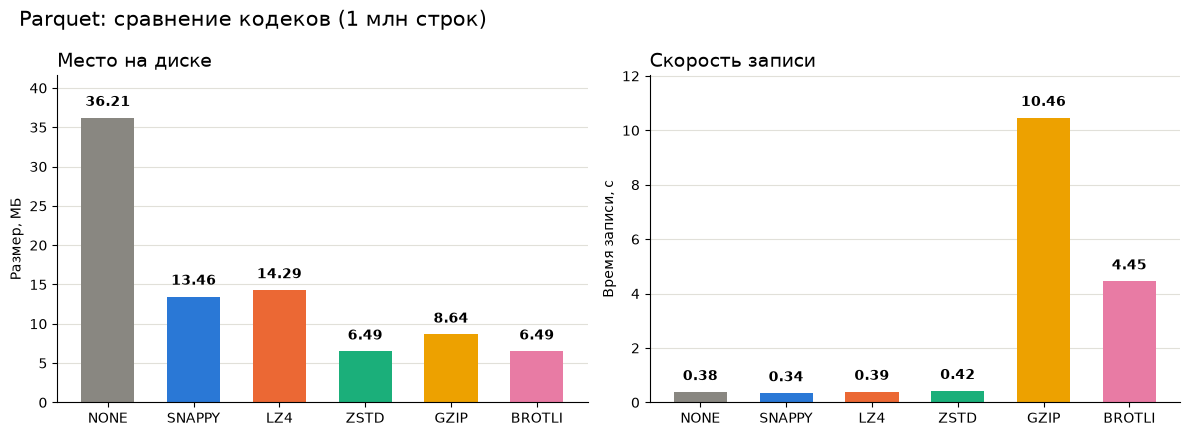

In [6]:
import matplotlib.pyplot as plt

color = {"NONE": "#898781", "SNAPPY": "#2a78d6", "LZ4": "#eb6834",
         "ZSTD": "#1baf7a", "GZIP": "#eda100", "BROTLI": "#e87ba4"}
bench["color"] = bench["codec"].map(color)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))
x = range(len(bench))
for ax, col, ylab in ((ax1, "size_mb", "Размер, МБ"), (ax2, "write_s", "Время записи, с")):
    bars = ax.bar(x, bench[col], color=bench["color"], width=0.62)
    for b, v in zip(bars, bench[col]):
        ax.text(b.get_x() + b.get_width()/2, v + max(bench[col])*0.03,
                f"{v:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_xticks(list(x)); ax.set_xticklabels(bench["codec"])
    ax.set_ylabel(ylab); ax.set_ylim(0, max(bench[col])*1.15)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e1e0d9"); ax.set_axisbelow(True)

ax1.set_title("Место на диске", loc="left", fontsize=14)
ax2.set_title("Скорость записи", loc="left", fontsize=14)
fig.suptitle("Parquet: сравнение кодеков (1 млн строк)", fontsize=15, x=0.02, ha="left")
fig.tight_layout()
plt.show()

## 6. Пишем в MinIO — это и есть физический слой lakehouse

In [7]:
import pyarrow.fs as pafs

fs = pafs.S3FileSystem(
    endpoint_override="http://localhost:9000",
    access_key="minioadmin", secret_key="minioadmin",
    scheme="http", region="us-east-1",
)

pq.write_table(tbl, "warehouse/compression-demo/orders_zstd.parquet",   filesystem=fs, compression="zstd")
pq.write_table(tbl, "warehouse/compression-demo/orders_snappy.parquet", filesystem=fs, compression="snappy")

for key in ["warehouse/compression-demo/orders_zstd.parquet",
            "warehouse/compression-demo/orders_snappy.parquet"]:
    info = fs.get_file_info(key)
    print(f"{key:52s} {info.size/1e6:8.2f} MB")

warehouse/compression-demo/orders_zstd.parquet           6.53 MB
warehouse/compression-demo/orders_snappy.parquet        13.46 MB


In [8]:
import boto3

s3 = boto3.client("s3", endpoint_url="http://localhost:9000",
                  aws_access_key_id="minioadmin", aws_secret_access_key="minioadmin",
                  region_name="us-east-1")
for o in s3.list_objects_v2(Bucket="warehouse", Prefix="compression-demo/").get("Contents", []):
    print(f"{o['Key']:52s} {o['Size']/1e6:8.2f} MB")

compression-demo/orders_snappy.parquet                  13.46 MB
compression-demo/orders_zstd.parquet                     6.53 MB


## 7. Iceberg в Trino: какой кодек по умолчанию

In [9]:
def trino(sql, catalog="lakekeeper", schema="lakehouse"):
    base = "http://localhost:8080/v1/statement"
    h = {"X-Trino-User": "trino", "X-Trino-Catalog": catalog, "X-Trino-Schema": schema}
    r = requests.post(base, data=sql.encode(), headers=h, timeout=300)
    j = r.json()
    if j.get("error"):
        raise RuntimeError(j["error"].get("message", str(j)))
    cols = [c["name"] for c in j.get("columns", [])]
    data = j.get("data") or []
    uri = j.get("nextUri")
    while uri:
        j = requests.get(uri, headers={"X-Trino-User": "trino"}, timeout=300).json()
        if j.get("error"):
            raise RuntimeError(j["error"].get("message", str(j)))
        data += j.get("data") or []
        uri = j.get("nextUri")
    return cols, data

trino("CREATE SCHEMA IF NOT EXISTS lakekeeper.lakehouse")
trino("DROP TABLE IF EXISTS lakekeeper.lakehouse.orders")
trino("""CREATE TABLE lakekeeper.lakehouse.orders (
    order_id   bigint,
    store_id   bigint,
    region     varchar,
    category   varchar,
    price      double,
    qty        integer,
    order_date varchar,
    is_promo   boolean
)""")
print("таблица orders создана")

таблица orders создана


In [10]:
trino("""INSERT INTO lakekeeper.lakehouse.orders
SELECT
    s,
    s % 200,
    CASE s % 5 WHEN 0 THEN 'Москва' WHEN 1 THEN 'СПб' WHEN 2 THEN 'Казань'
               WHEN 3 THEN 'Екатеринбург' ELSE 'Новосибирск' END,
    CASE s % 3 WHEN 0 THEN 'Электроника' WHEN 1 THEN 'Одежда' ELSE 'Продукты' END,
    10.0 * (s % 1000),
    s % 10,
    '2024-01-01',
    (s % 2 = 0)
FROM UNNEST(sequence(1, 9000)) AS t(s)""")

cols, data = trino("SELECT count(*) AS n FROM lakekeeper.lakehouse.orders")
print("строк в таблице:", data[0][0])

строк в таблице: 9000


In [11]:
files = []
for o in s3.list_objects_v2(Bucket="warehouse", Prefix="orders-").get("Contents", []):
    if o["Key"].endswith(".parquet"):
        files.append(o["Key"])
print("parquet-файлы Iceberg-таблицы:")
for k in files:
    print("  ", k)

if files:
    md_meta = pq.read_metadata("warehouse/" + files[0], filesystem=fs)
    c0 = md_meta.row_group(0).column(0)
    print("\nкодек первой колонки (и по умолчанию для Iceberg):", c0.compression)

parquet-файлы Iceberg-таблицы:
   orders-763687162f534009b1a5064ded43070f/data/20261002_212026_00004_xqvrg-c45c4a1c-3636-4a14-ba00-c2a438c96269.parquet

кодек первой колонки (и по умолчанию для Iceberg): ZSTD


**Как поменять кодек.** В Trino кодек Iceberg — это каталог-свойство `iceberg.compression-codec` (значения `NONE | SNAPPY | LZ4 | ZSTD | GZIP`, по умолчанию `ZSTD`). Добавь строку в `catalog/lakekeeper.properties`:

```properties
iceberg.compression-codec=GZIP
```

и перезапусти Trino: `docker restart trino`.

In [12]:
trino("DROP TABLE IF EXISTS lakekeeper.lakehouse.orders")
for o in s3.list_objects_v2(Bucket="warehouse", Prefix="compression-demo/").get("Contents", []):
    s3.delete_object(Bucket="warehouse", Key=o["Key"])
print("демо-данные удалены")

демо-данные удалены


In [13]:
print("Быстрее всего ПИШЕТ (write_s, сек):")
print(bench.sort_values("write_s")[["codec", "write_s"]].round(3).to_string(index=False))
print()
print("Сильнее всего СЖИМАЕТ (size_mb, МБ):")
print(bench.sort_values("size_mb")[["codec", "size_mb"]].round(2).to_string(index=False))

Быстрее всего ПИШЕТ (write_s, сек):
 codec  write_s
SNAPPY    0.341
  NONE    0.383
   LZ4    0.392
  ZSTD    0.424
BROTLI    4.452
  GZIP   10.461

Сильнее всего СЖИМАЕТ (size_mb, МБ):
 codec  size_mb
  ZSTD     6.49
BROTLI     6.49
  GZIP     8.64
SNAPPY    13.46
   LZ4    14.29
  NONE    36.21


## 8. Выводы

**Скорость записи (быстрее → медленнее):** LZ4 ≈ Snappy → ZSTD → gzip-9 ≈ Brotli.

**Степень сжатия (слабее → сильнее):** NONE → LZ4 ≈ Snappy → ZSTD → gzip-9 ≈ Brotli.

**Что для чего брать:**

| Сценарий | Кодек |
|----------|-------|
| Горячие данные | LZ4 / Snappy |
| Баланс (дефолт Iceberg) | ZSTD-3 |
| Холодные / архив | ZSTD-высокий или gzip-9 |